In [3]:
suppressMessages(library(ArchR))
suppressMessages(library(Seurat))
suppressMessages(library(Signac))
suppressMessages(library(ggplot2))
suppressMessages(library(cowplot))
suppressMessages(library(rtracklayer))

In [4]:
addArchRThreads(threads = 32)

Setting default number of Parallel threads to 32.



In [5]:
out_dir = '../../results/04_single_cell_access_atac/15_find_markers'

# create output directory
if (!dir.exists(out_dir)) {
  dir.create(out_dir, recursive = TRUE)
}

In [6]:
proj <- loadArchRProject("../../results/04_single_cell_access_atac/13_create_archr_project", showLogo = FALSE)

Successfully loaded ArchRProject!



In [7]:
obj <- readRDS("../../results/04_single_cell_access_atac/14_create_seurat/obj.rds")

In [8]:
obj

An object of class Seurat 
140697 features across 2479 samples within 1 assay 
Active assay: ATAC (140697 features, 139315 variable features)
 2 layers present: counts, data
 2 dimensional reductions calculated: lsi, umap_atac

In [9]:
## add clusters to ArchR project
clusters <- obj@meta.data[rownames(proj@cellColData), "seurat_clusters"]

proj <- addCellColData(proj, 
                       data = as.character(clusters), 
                       name = "Clusters", 
                       cells = rownames(proj@cellColData), 
                       force = TRUE)

In [10]:
## add UMAP embedding
embedding <- obj@reductions$umap@cell.embeddings
embedding <- embedding[rownames(proj@cellColData), ]

colnames(embedding) <- c("LSI#UMAP_Dimension_1",
                         "LSI#UMAP_Dimension_2")

proj@embeddings[["umap"]] <- SimpleList(df = as.data.frame(embedding),
                                        params = NULL)

ArchR logging to : ArchRLogs/ArchR-plotEmbedding-3e79bb22eb49dd-Date-2026-01-15_Time-15-27-42.918784.log
If there is an issue, please report to github with logFile!

Getting UMAP Embedding

ColorBy = cellColData

Plotting Embedding

1 


ArchR logging successful to : ArchRLogs/ArchR-plotEmbedding-3e79bb22eb49dd-Date-2026-01-15_Time-15-27-42.918784.log



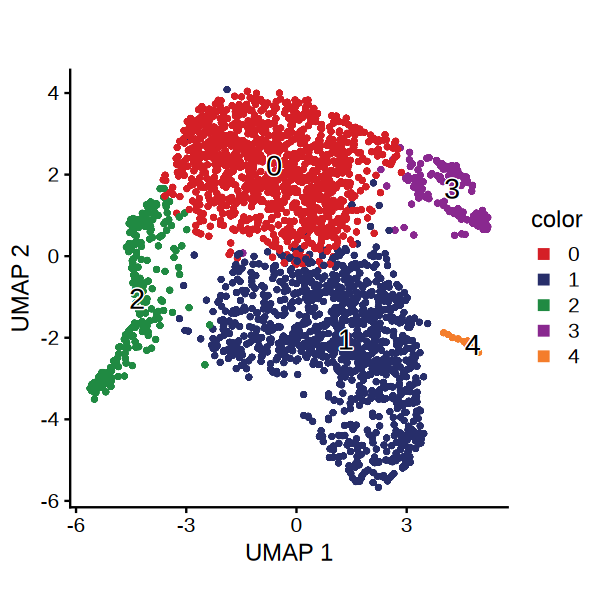

In [11]:
p <- plotEmbedding(ArchRProj = proj,
                   embedding = "umap",
                   colorBy = "cellColData",
                   name = "Clusters",
                   baseSize = 50,
                   size = 3,
                  labelSize = 6,
                  labelAsFactors = FALSE) +
    theme_cowplot() +
    xlab("UMAP 1") + ylab("UMAP 2") +
    ggtitle("")

options(repr.plot.height = 5, repr.plot.width = 5)

print(p)

In [14]:
getAvailableMatrices(proj)

[1] "GeneScoreMatrix" "PeakMatrix"      "TileMatrix"

In [16]:
proj <- addIterativeLSI(
    ArchRProj = proj,
    useMatrix = "PeakMatrix", 
    name = "IterativeLSI", 
    iterations = 1, 
    varFeatures = 141371, 
    dimsToUse = 1:15,
    force = TRUE
)

Checking Inputs...

ArchR logging to : ArchRLogs/ArchR-addIterativeLSI-3e79bb1178e06a-Date-2026-01-15_Time-15-38-07.56671.log
If there is an issue, please report to github with logFile!

2026-01-15 15:38:07.922124 : Computing Total Across All Features, 0.001 mins elapsed.

2026-01-15 15:38:08.442405 : Computing Top Features, 0.009 mins elapsed.

Not Enough Non-Zero Features to Filter!

###########
2026-01-15 15:38:09.231051 : Running LSI (1 of 1) on Top Features, 0.023 mins elapsed.
###########

2026-01-15 15:38:09.270094 : Creating Partial Matrix, 0.023 mins elapsed.

2026-01-15 15:38:14.601021 : Computing LSI, 0.112 mins elapsed.

2026-01-15 15:38:25.57002 : Finished Running IterativeLSI, 0.295 mins elapsed.



In [17]:
proj <- addImputeWeights(proj, dimsToUse = 2:15, scaleDims = TRUE)

ArchR logging to : ArchRLogs/ArchR-addImputeWeights-3e79bb43908d20-Date-2026-01-15_Time-15-38-42.9029.log
If there is an issue, please report to github with logFile!

2026-01-15 15:38:43.187561 : Computing Impute Weights Using Magic (Cell 2018), 0 mins elapsed.



In [18]:
markerGenes  <- c(
    "Aqp3",  # NK cells
    "Scgb1a1",  # Club cells
    "Foxj1"  # Ciliated cells
    )

In [28]:
p1 <- plotEmbedding(ArchRProj = proj,
                    colorBy = "GeneScoreMatrix",
                    name = "Aqp3",
                    embedding = "umap",
                    plotAs = "points",
                   size = 3) +
    theme_cowplot() +
    xlab("UMAP1") + ylab("UMAP2") +
    ggtitle("Aqp3") +
    theme(legend.title = element_blank())

p2 <- plotEmbedding(ArchRProj = proj,
                    colorBy = "GeneScoreMatrix",
                    name = "Scgb1a1",
                    embedding = "umap",
                    plotAs = "points",
                   size = 3) +
    theme_cowplot() +
        xlab("UMAP1") + ylab("UMAP2") +
    ggtitle("Scgb1a1") +
        theme(legend.title = element_blank())

p3 <- plotEmbedding(ArchRProj = proj,
                    colorBy = "GeneScoreMatrix",
                    name = "Foxj1",
                    embedding = "umap",
                    plotAs = "points",
                   size = 3) +
    theme_cowplot() +
        xlab("UMAP1") + ylab("UMAP2") +
    ggtitle("Foxj1") +
        theme(legend.title = element_blank())

Getting ImputeWeights

ArchR logging to : ArchRLogs/ArchR-plotEmbedding-3e79bb66018baf-Date-2026-01-15_Time-15-44-43.228602.log
If there is an issue, please report to github with logFile!

Getting UMAP Embedding

ColorBy = GeneScoreMatrix

Getting Matrix Values...

2026-01-15 15:44:43.650351 : 

1 


Imputing Matrix

Using weights on disk

1 of 1

Plotting Embedding

1 


ArchR logging successful to : ArchRLogs/ArchR-plotEmbedding-3e79bb66018baf-Date-2026-01-15_Time-15-44-43.228602.log

Getting ImputeWeights

ArchR logging to : ArchRLogs/ArchR-plotEmbedding-3e79bb40d4fc2b-Date-2026-01-15_Time-15-44-45.538705.log
If there is an issue, please report to github with logFile!

Getting UMAP Embedding

ColorBy = GeneScoreMatrix

Getting Matrix Values...

2026-01-15 15:44:45.853262 : 

1 


Imputing Matrix

Using weights on disk

1 of 1

Plotting Embedding

1 


ArchR logging successful to : ArchRLogs/ArchR-plotEmbedding-3e79bb40d4fc2b-Date-2026-01-15_Time-15-44-45.538705.log

Getting ImputeWe

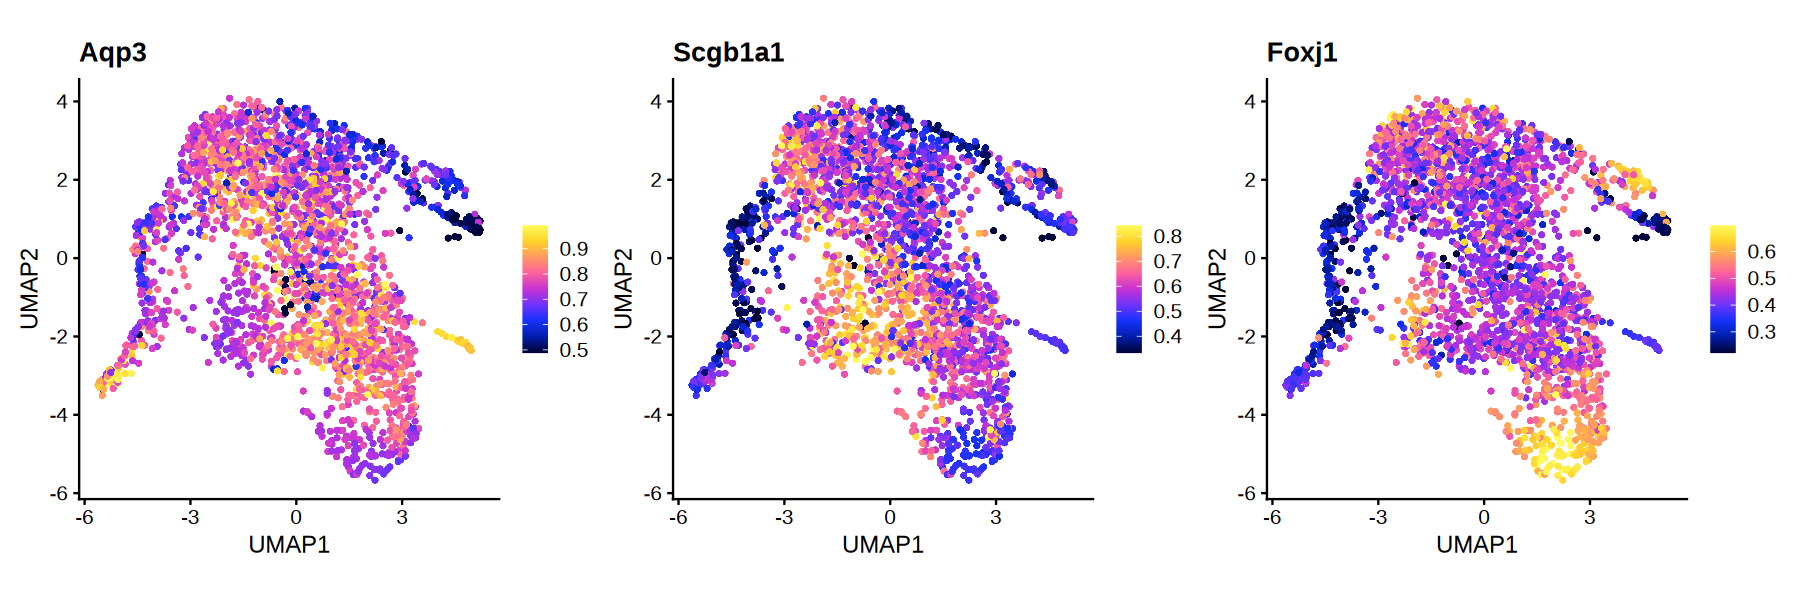

In [29]:
options(repr.plot.height = 5, repr.plot.width = 15)

p1 + p2 + p3

In [31]:
features <- list(
  BasalCellScore = c("Aqp3", "Krt5", "Dapl1", "Hspa1a", "Trp64"),
  ClubCellScore = c("Scgb1a1", "Krt15", "Cbr2", "Cyp2f2", "Lypd2"),
  CiliatedCellScore = c("Foxj1", "Ccdc153", "Ccdc113", "Mlf1", "Lztfl1")
)

proj <- addModuleScore(proj,
    useMatrix = "GeneScoreMatrix",
    name = "Module",
    features = features)

ArchR logging to : ArchRLogs/ArchR-addModuleScore-3e79bb21e66004-Date-2026-01-15_Time-15-52-56.523716.log
If there is an issue, please report to github with logFile!



ERROR: Error in .Call2("map_positions", run_lens, pos, method, PACKAGE = "S4Vectors"): subscript contains NAs


In [21]:
markersGS <- getMarkerFeatures(
    ArchRProj = proj, 
    useMatrix = "GeneScoreMatrix", 
    groupBy = "Clusters",
    bias = c("TSSEnrichment", "log10(nFrags)"),
    testMethod = "wilcoxon"
)

ArchR logging to : ArchRLogs/ArchR-getMarkerFeatures-3e79bb2b446ec6-Date-2026-01-15_Time-15-40-21.536573.log
If there is an issue, please report to github with logFile!

MatrixClass = Sparse.Double.Matrix

2026-01-15 15:40:22.025257 : Matching Known Biases, 0.002 mins elapsed.

###########
2026-01-15 15:40:50.658375 : Completed Pairwise Tests, 0.479 mins elapsed.
###########

ArchR logging successful to : ArchRLogs/ArchR-getMarkerFeatures-3e79bb2b446ec6-Date-2026-01-15_Time-15-40-21.536573.log



In [22]:
heatmapGS <- plotMarkerHeatmap(
  seMarker = markersGS, 
  cutOff = "FDR <= 0.05 & Log2FC >= 0.5", 
  #labelMarkers = markerGenes,
  transpose = TRUE
)

ArchR logging to : ArchRLogs/ArchR-plotMarkerHeatmap-3e79bb541c9b6c-Date-2026-01-15_Time-15-41-03.179269.log
If there is an issue, please report to github with logFile!

Printing Top Marker Genes:

0:

	4930448I06Rik, Gm37864, Gm37218, Ulbp1, 4930471D02Rik, Or2y17, Or4d2b, Gm33308, 1700092E19Rik, Gm48703, Gm16132, Crisp3, Atg13, Wfdc6a, Dnajc19

1:

	Vcpip1, 1700034P13Rik, Lgsn, Bag2, Gm28306, Mfsd9, Gm28319, Hspd1, Hspe1, Aox1, Flacc1, Nop58, Bmpr2, D630023F18Rik, Rufy4

2:

	ENSMUSG00000121448, 2610035D17Rik, Tgm1, Tnfrsf11b, Ldlrad4, Gm41764, Malat1, Gm13686, Trim69, Ecm1, Cldn4, Gm31774, Sema7a, Vcpip1, 1700034P13Rik

3:

	Ccdc170, Evl, Gm50328, Kif6, Dgki, Irag2, Tox3, Pou2f3, Vcpip1, 1700034P13Rik, Lgsn, Bag2, Gm28306, Mfsd9, 4930448I06Rik

4:

	Vcpip1, 1700034P13Rik, Lgsn, Bag2, Gm28306, Mfsd9, 4930448I06Rik, Gm28319, Hspd1, Hspe1, Aox1, Flacc1, Nop58, Bmpr2, D630023F18Rik

Identified 813 markers!



 [1] "4930448I06Rik"      "Gm37864"            "Gm37218"           
 [4] "Ulbp1"              "4930471D02Rik"      "Or2y17"            
 [7] "Or4d2b"             "Gm33308"            "1700092E19Rik"     
[10] "Gm48703"            "Gm16132"            "Crisp3"            
[13] "Atg13"              "Wfdc6a"             "Dnajc19"           
[16] "Vcpip1"             "1700034P13Rik"      "Lgsn"              
[19] "Bag2"               "Gm28306"            "Mfsd9"             
[22] "Gm28319"            "Hspd1"              "Hspe1"             
[25] "Aox1"               "Flacc1"             "Nop58"             
[28] "Bmpr2"              "D630023F18Rik"      "Rufy4"             
[31] "ENSMUSG00000121448" "2610035D17Rik"      "Tgm1"              
[34] "Tnfrsf11b"          "Ldlrad4"            "Gm41764"           
[37] "Malat1"             "Gm13686"            "Trim69"            
[40] "Ecm1"               "Cldn4"              "Gm31774"           
[43] "Sema7a"             "Ccdc170"            "

Adding Annotations..

Preparing Main Heatmap..

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.

ArchR logging successful to : ArchRLogs/ArchR-plotMarkerHeatmap-3e79bb541c9b6c-Date-2026-01-15_Time-15-41-03.179269.log



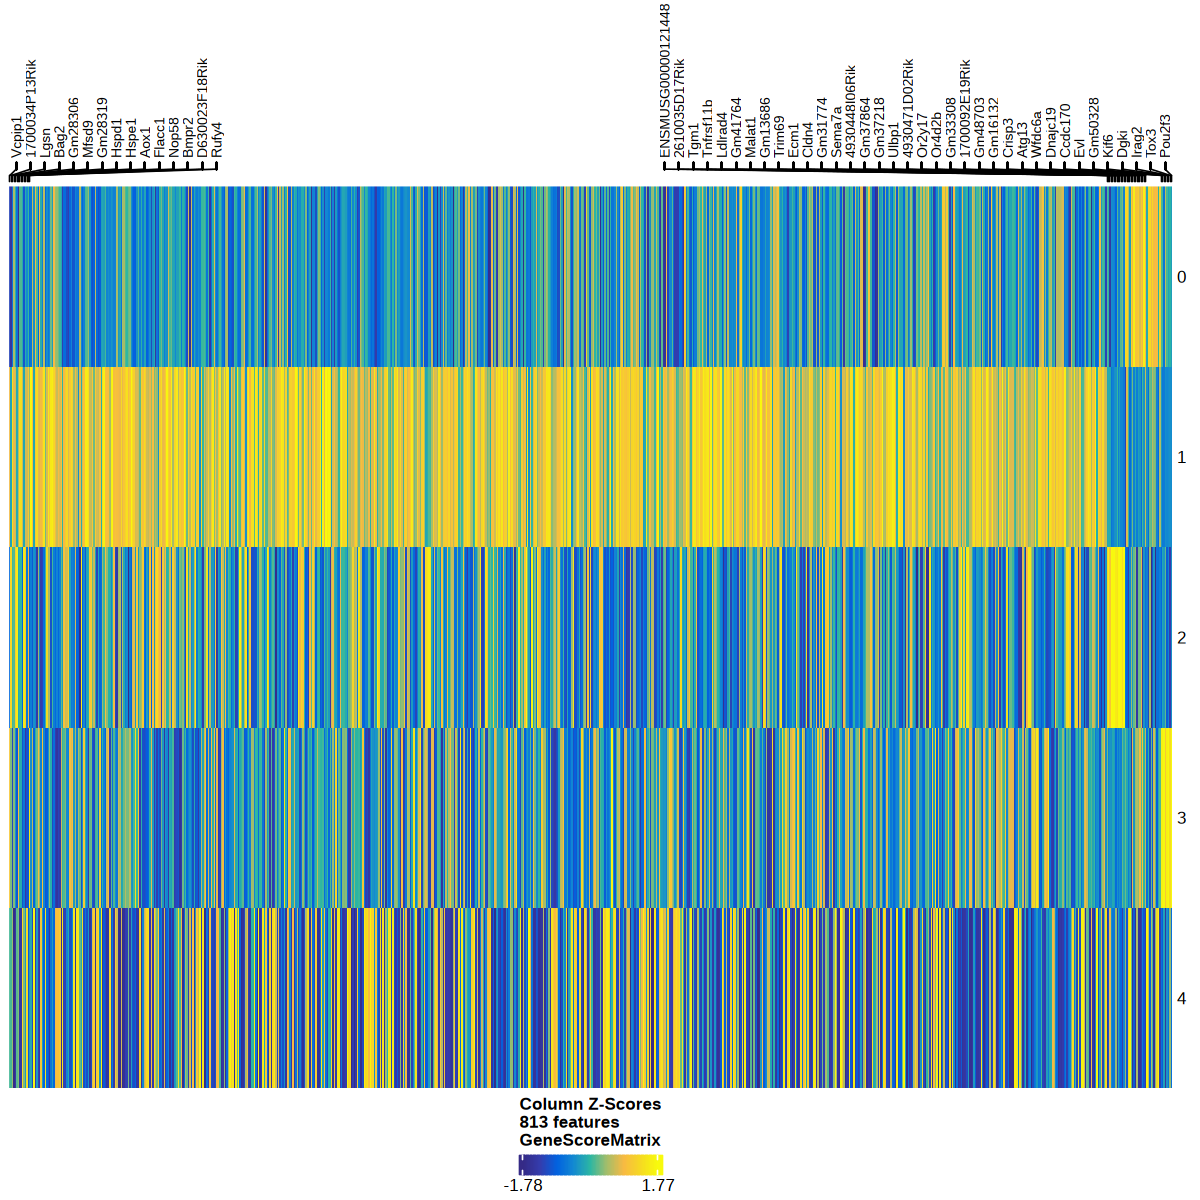

In [23]:
options(repr.plot.height = 10, repr.plot.width = 10)
ComplexHeatmap::draw(heatmapGS, heatmap_legend_side = "bot", annotation_legend_side = "bot")

In [ ]:
markerGenes  <- c(
    "Aqp3",  # NK cells
    "Scgb1a1",  # Club cells
    "Foxj1"  # Ciliated cells
    )

In [ ]:
p <- plotEmbedding(
    ArchRProj = proj, 
    colorBy = "GeneScoreMatrix", 
    name = markerGenes, 
    embedding = "umap",
    quantCut = c(0.01, 0.95),
    imputeWeights = NULL
)

In [ ]:
options(repr.plot.height = 10, repr.plot.width = 10)
print(p$Aqp3)

In [ ]:
p <- plotBrowserTrack(
    ArchRProj = proj, 
    groupBy = "Clusters", 
    geneSymbol = markerGenes, 
    upstream = 10000,
    downstream = 10000
)

In [ ]:
grid::grid.newpage()
grid::grid.draw(p$Aqp3)

In [ ]:
grid::grid.newpage()
grid::grid.draw(p$Scgb1a1)

In [ ]:
grid::grid.newpage()
grid::grid.draw(p$Foxj1)

In [24]:
## Save data
saveArchRProject(ArchRProj = proj)

Saving ArchRProject...

Loading ArchRProject...

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
         

class: ArchRProject 
outputDirectory: /data/pinello/PROJECTS/2025_06_ZL_ACCESS/results/35_scACCESS_mouseAirwayCell/13_create_archr_project 
samples(1): mouse
sampleColData names(1): ArrowFiles
cellColData names(16): Sample TSSEnrichment ... FRIP Clusters
numberOfCells(1): 2479
medianTSS(1): 11.635
medianFrags(1): 3380

In [25]:
saveRDS(markersGS, file = file.path(out_dir, "markersGS.rds"))

In [26]:
## Session information
sessionInfo()

R version 4.4.3 (2025-02-28)
Platform: x86_64-conda-linux-gnu
Running under: Ubuntu 20.04.6 LTS

Matrix products: default
BLAS/LAPACK: /data/pinello/SHARED_SOFTWARE/envs/zl002_envs/zl_access/lib/libopenblasp-r0.3.30.so;  LAPACK version 3.12.0

Random number generation:
 RNG:     L'Ecuyer-CMRG 
 Normal:  Inversion 
 Sample:  Rejection 
 
locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Etc/UTC
tzcode source: system (glibc)

attached base packages:
 [1] parallel  stats4    grid      stats     graphics  grDevices utils    
 [8] datasets  methods   base     

other attached packages:
 [1] circlize_0.4.16             ComplexHeatmap_2.22.0      
 [3] nabor_0.5.0           